## EDA

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- portable paths: resolve the project root from ANY working directory ---
import sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "API").is_dir())
sys.path.insert(0, str(_ROOT))
from paths import PANEL_CSV

df = pd.read_csv(PANEL_CSV, low_memory=False)
df_og = df.copy()
df.shape

/var/folders/46/d5hrdlzn2hg_3s9hb3w6dcl40000gn/T/ipykernel_95763/3264442413.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/natchalin_/Desktop/final_project/Lloyds/API/panel.csv")


(2117863, 15)

In [44]:
df.head()

,com_num,name,T,week,age_years,sector,region,account_type,accounts_overdue,prior_nonlloyds_charges,tone_z,vol_z,z_source,media_missing,label
0,15073164,NFLECTION ADVISORY LIMITED,2024-10-13,2024-10-13,1.163587,M: Professional/Scientific,NaN,total-exemption-full,False,0,NaN,NaN,NaN,1,0
1,13522064,NFOGENIE LTD,2024-10-13,2024-10-13,3.230664,J: Information/Comms,NaN,micro-entity,False,0,NaN,NaN,NaN,1,0
2,11006939,NNOV8 LIMITED,2024-10-13,2024-10-13,7.006160,J: Information/Comms,NaN,micro-entity,False,0,NaN,NaN,NaN,1,0
3,SC606050,NSPIRED INVESTMENTS LTD,2024-10-13,2024-10-13,6.143737,L: Real Estate,NaN,total-exemption-full,False,5,NaN,NaN,NaN,1,0
4,11303802,"""1ST RATE"" PSYCHOLOGY SERVICES LTD",2024-10-13,2024-10-13,6.507871,P: Education,NaN,micro-entity,False,0,NaN,NaN,NaN,1,0


In [45]:
df[df.columns[8]].apply(type).value_counts()

accounts_overdue
<class 'str'>     1900544
<class 'bool'>     217319
Name: count, dtype: int64

In [46]:
df.dtypes

com_num                     object
name                        object
T                           object
week                        object
age_years                  float64
sector                      object
region                      object
account_type                object
accounts_overdue            object
prior_nonlloyds_charges      int64
tone_z                     float64
vol_z                      float64
z_source                    object
media_missing                int64
label                        int64
dtype: object

In [47]:
df.isnull().sum()

com_num                         0
name                            0
T                               0
week                            0
age_years                       0
sector                         21
region                      94508
account_type                    0
accounts_overdue                0
prior_nonlloyds_charges         0
tone_z                     236870
vol_z                      235458
z_source                   235458
media_missing                   0
label                           0
dtype: int64

### Check missing values: "media_missing", "tone_z", and "vol_z"

In [48]:
df["media_missing"].value_counts()

media_missing
0    1880993
1     236870
Name: count, dtype: int64

In [49]:
tone_missing = df["tone_z"].isnull()
vol_missing = df["vol_z"].isnull()

print((df["media_missing"] == tone_missing).all())
print((df["media_missing"] == vol_missing).all())

True
False


In [50]:
print("vol_z missing, tone_z NOT:", (vol_missing & ~tone_missing).sum())
print("tone_z missing, vol_z NOT:", (tone_missing & ~vol_missing).sum())
print("Both missing :", (tone_missing & vol_missing).sum())

vol_z missing, tone_z NOT: 0
tone_z missing, vol_z NOT: 1412
Both missing : 235458


This means if "vol_z" is NaN --> "tone_z" will always be NaN, but not vice versa

In [51]:
df["z_source"].value_counts()

z_source
cell               1178302
sector-fallback     704103
Name: count, dtype: int64

### Check "Label"

In [52]:
df["label"].value_counts()

label
0    2117437
1        426
Name: count, dtype: int64

In [53]:
df["label"].value_counts(normalize=True) * 100

label
0    99.979885
1     0.020115
Name: proportion, dtype: float64

In [54]:
df[df["label"] == 1].groupby("T").size()

T
2024-10-13    35
2025-01-12    62
2025-04-13    36
2025-07-13    40
2025-10-12    73
2026-01-11    92
2026-04-12    88
dtype: int64

In [55]:
Timeframes = sorted(df["T"].unique())

t1_5 = df[df["T"].isin(Timeframes[:5])]
t6_7 = df[df["T"].isin(Timeframes[5:])]

print(f"T1-5: {len(t1_5)} ({len(t1_5)/len(df)*100:.2f}%)")
print(f"T6-7: {len(t6_7)} ({len(t6_7)/len(df)*100:.2f}%)")


T1-5: 1510617 (71.33%)
T6-7: 607246 (28.67%)


In [56]:
t1_5_lloyds = (t1_5["label"]==1).sum()
t6_7_lloyds = (t6_7["label"]==1).sum()
print(f"T1-5: {t1_5_lloyds} ({t1_5_lloyds/(t1_5_lloyds+t6_7_lloyds)*100:.4f}%)")
print(f"T6-7: {t6_7_lloyds} ({t6_7_lloyds/(t1_5_lloyds+t6_7_lloyds)*100:.4f}%)")

T1-5: 246 (57.7465%)
T6-7: 180 (42.2535%)


### Check Unique Values


In [57]:
df.nunique()

com_num                    303919
name                       303918
T                               7
week                            7
age_years                   23528
sector                         21
region                         12
account_type                    5
accounts_overdue                5
prior_nonlloyds_charges       135
tone_z                        924
vol_z                         927
z_source                        2
media_missing                   2
label                           2
dtype: int64

In [58]:
df["accounts_overdue"].unique()

array(['False', 'True', 'unknown', False, True], dtype=object)

NOTE:
- EXTREME CLASS IMBALANCE 0.024759% and 99.975241%
- Identifier cols: "com_num", "name"
- Category Cols: "sector", "region", "account_type"
- Target col: "label"
- The number of missing value in "tone_z" is exactly the same as in "media_missing"
- "media_missing" indicates missing values in "tone_z", NOT "vol_z"
- 0 in a z-score has meaning, so filling missing values with "0" in "tone_z" and "vol_z" might impact the model?
- Train/Test split by Timeframe --> Timeframe 1-5 = Train, Timeframe 6-7 = Test



CLEAN:
- Drop "week"
- Drop "z_source"
- Drop rows with missing "region", "sector", "accounts_overdue"
- Change 5 diff unique values in "account_overdue" --> int 0/1
- Fill missing value with 0 in "tone_z" as we already have "missing_media" column
- Create a new flag column "vol_missing" for "vol_z"
- Fill missing value with 0 in "vol_z"



## CLEANING

In [59]:
# Drop unused columns + rows with missing "sector"
df= df.drop(columns=["week", "z_source"])
df = df.dropna(subset=["sector"])

#### Note: I found that dropping rows with missing "region" value removes 1 positive-class data (name "1916 HOLDINGS LIMITED" | com_num "15832841"). Since we have very limited data, I think it is better to impute rather than drop

In [60]:
# Mode imputation
mode_region = df["region"].mode()[0]
df["region"] = df["region"].fillna(mode_region)

In [61]:
# Change values in "accounts_overdue" to Boolean
accounts_overdue_map = {
    "True": True, 
    True: True,
    "False": False, 
    False: False,
    "unknown": np.nan,
}

df["accounts_overdue"] = df["accounts_overdue"].map(accounts_overdue_map)
df["accounts_overdue"].value_counts(dropna=False)


accounts_overdue
False    2087753
True       30033
NaN           56
Name: count, dtype: int64

In [62]:
# Drop rows with missing "accounts_overdue"
df = df.dropna(subset=["accounts_overdue"])

# Change data type to int
df["accounts_overdue"] = df["accounts_overdue"].astype(int)

In [63]:
# Create a new column "vol_missing"
df["vol_missing"] = df["vol_z"].isnull().astype(int)

# fill missing values with "0"
df["tone_z"] = df["tone_z"].fillna(0)
df["vol_z"] = df["vol_z"].fillna(0)

In [64]:
df.isnull().sum()

com_num                    0
name                       0
T                          0
age_years                  0
sector                     0
region                     0
account_type               0
accounts_overdue           0
prior_nonlloyds_charges    0
tone_z                     0
vol_z                      0
media_missing              0
label                      0
vol_missing                0
dtype: int64

In [65]:
df.head()

,com_num,name,T,age_years,sector,region,account_type,accounts_overdue,prior_nonlloyds_charges,tone_z,vol_z,media_missing,label,vol_missing
0,15073164,NFLECTION ADVISORY LIMITED,2024-10-13,1.163587,M: Professional/Scientific,London,total-exemption-full,0,0,0.0,0.0,1,0,1
1,13522064,NFOGENIE LTD,2024-10-13,3.230664,J: Information/Comms,London,micro-entity,0,0,0.0,0.0,1,0,1
2,11006939,NNOV8 LIMITED,2024-10-13,7.006160,J: Information/Comms,London,micro-entity,0,0,0.0,0.0,1,0,1
3,SC606050,NSPIRED INVESTMENTS LTD,2024-10-13,6.143737,L: Real Estate,London,total-exemption-full,0,5,0.0,0.0,1,0,1
4,11303802,"""1ST RATE"" PSYCHOLOGY SERVICES LTD",2024-10-13,6.507871,P: Education,London,micro-entity,0,0,0.0,0.0,1,0,1


In [66]:
Timeframes = sorted(df["T"].unique())

t1_5 = df[df["T"].isin(Timeframes[:5])]
t6_7 = df[df["T"].isin(Timeframes[5:])]

print(f"T1-5: {len(t1_5)} ({len(t1_5)/len(df)*100:.2f}%)")
print(f"T6-7: {len(t6_7)} ({len(t6_7)/len(df)*100:.2f}%)")

T1-5: 1510562 (71.33%)
T6-7: 607224 (28.67%)


In [67]:
t1_5_lloyds = (t1_5["label"]==1).sum()
t6_7_lloyds = (t6_7["label"]==1).sum()
print(f"T1-5: {t1_5_lloyds} ({t1_5_lloyds/(t1_5_lloyds+t6_7_lloyds)*100:.4f}%)")
print(f"T6-7: {t6_7_lloyds} ({t6_7_lloyds/(t1_5_lloyds+t6_7_lloyds)*100:.4f}%)")

T1-5: 246 (57.7465%)
T6-7: 180 (42.2535%)


In [68]:
# Check which company was removed

# not_clean = df_og[df_og["label"]==1]["com_num"]
# cleaned = df[df["label"]==1]["com_num"]

# missing_com = set(not_clean) - set(cleaned)
# print(missing_com)

In [69]:
# df_og[df_og["com_num"] == "15832841"]

Summary:

- "week" and "z_source" dropped
- rows missing "sector" dropped
- Mode-imputed "region"
- "accounts_overdue" --> "unknown" rows dropped + converted to Boolean(int 0/1)
- missing values in "tone_z" and "vol_z" filled with 0
- add column "vol_missing"

In [70]:
df.to_csv("panel_cleaned.csv", index=False)

## MODELING

In [71]:
df.dtypes

com_num                     object
name                        object
T                           object
age_years                  float64
sector                      object
region                      object
account_type                object
accounts_overdue             int64
prior_nonlloyds_charges      int64
tone_z                     float64
vol_z                      float64
media_missing                int64
label                        int64
vol_missing                  int64
dtype: object

In [72]:
num_cols = ["age_years", "prior_nonlloyds_charges", "tone_z", "vol_z"]
cat_cols = ["sector", "region", "account_type"]
bool_cols = ["accounts_overdue", "media_missing", "vol_missing"]
target_col = "label"

feature_cols = cat_cols + num_cols + bool_cols
feature_cols

['sector',
 'region',
 'account_type',
 'age_years',
 'prior_nonlloyds_charges',
 'tone_z',
 'vol_z',
 'accounts_overdue',
 'media_missing',
 'vol_missing']

In [73]:
Timeframes = sorted(df["T"].unique())

train_df = df[df["T"].isin(Timeframes[:5])] # T1-5 = Train set
test_df = df[df["T"].isin(Timeframes[5:])] # T6-7 = Test set

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

### Logistic Regression

In [74]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

RS = 42

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RS)

pipe_lr = Pipeline([
    ("prep", preprocess),
    ("clf", model)
])

pipe_lr.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve, roc_curve

y_pred_lr = pipe_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

                     precision    recall  f1-score   support

NOT Lloyds Customer       1.00      0.75      0.86    607044
    Lloyds Customer       0.00      0.70      0.00       180

           accuracy                           0.75    607224
          macro avg       0.50      0.73      0.43    607224
       weighted avg       1.00      0.75      0.86    607224



In [76]:
confusion_matrix(y_test, y_pred_lr)

array([[455833, 151211],
       [    54,    126]])

In [77]:
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"ROC-AUC: {auc_lr}")

ROC-AUC: 0.8076795778669531


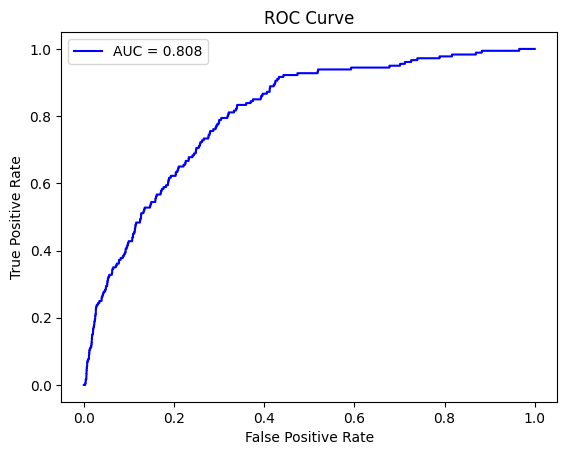

In [78]:
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr, tpr, color="blue", label=f"AUC = {auc_lr:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [79]:
ap_lr = average_precision_score(y_test, y_proba_lr)
print(f"Average Precision: {ap_lr}")

Average Precision: 0.001302447312979752


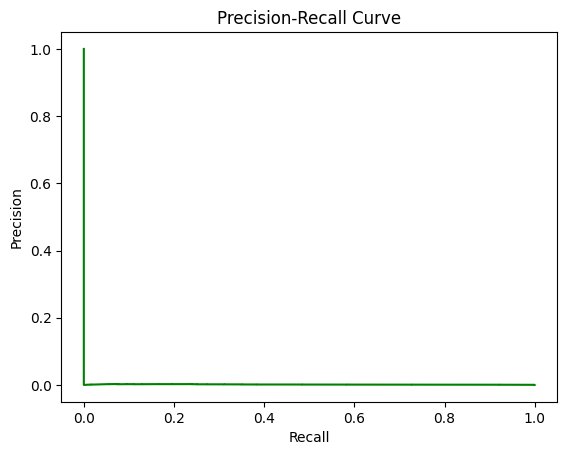

In [80]:
prec, rec, _ = precision_recall_curve(y_test, y_proba_lr)
plt.plot(rec, prec, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

### Precision@100 per cutoff

The `classification_report` above uses a 0.5 threshold, which is meaningless at 0.03% prevalence with balanced weights (it flags ~26k firms to catch 31). In deployment we never threshold — we hand RMs a ranked **top-K** list. So the real metric is **Precision@K per cutoff**: of the 100 highest-scored firms in each weekly list, how many actually converted — judged against the random base rate (→ lift) and the achievable ceiling `min(#positives, K)/K`.

In [81]:
# === Precision@K per cutoff (the deployment-realistic metric) ===
# Each test cutoff = one weekly ranked list an RM would actually work. So we
# score Precision@K PER cutoff (not pooled), and compare each to:
#   base  = random floor (the cutoff's true prevalence)  -> lift = prec / base
#   ceil  = best achievable = min(#positives, K) / K     (can't beat this)
def precision_at_k(y_true, y_score, k):
    order = np.argsort(y_score)[::-1][:k]      # positions of the top-k highest scores
    top = y_true[order]
    return top.mean(), int(top.sum())

K = 100
rows = []
for T in Timeframes[5:]:                        # test cutoffs only (T6, T7)
    sub   = test_df[test_df["T"] == T]
    yc    = sub[target_col].to_numpy()
    score = pipe_lr.predict_proba(sub[feature_cols])[:, 1]
    prec, hits = precision_at_k(yc, score, K)
    base = yc.mean()
    ceil = min(int(yc.sum()), K) / K
    rows.append({"T": T, "rows": len(yc), "positives": int(yc.sum()),
                 f"hits@{K}": hits, f"prec@{K}": prec, "base_rate": base,
                 "lift": prec / base if base else np.nan, f"ceiling@{K}": ceil})
    print(f"{T}:  Prec@{K} = {prec:6.1%}  ({hits}/{K} hits)   "
          f"base = {base:.3%}   lift = {prec/base:4.0f}x   ceiling = {ceil:.0%}")

results = pd.DataFrame(rows)
print(f"\nMean Prec@{K} across {len(rows)} cutoffs: {results[f'prec@{K}'].mean():.1%}"
      f"   (range {results[f'prec@{K}'].min():.1%} - {results[f'prec@{K}'].max():.1%})")
results

2026-01-11:  Prec@100 =   0.0%  (0/100 hits)   base = 0.030%   lift =    0x   ceiling = 92%
2026-04-12:  Prec@100 =   0.0%  (0/100 hits)   base = 0.029%   lift =    0x   ceiling = 88%

Mean Prec@100 across 2 cutoffs: 0.0%   (range 0.0% - 0.0%)


,T,rows,positives,hits@100,prec@100,base_rate,lift,ceiling@100
0,2026-01-11,303654,92,0,0.0,0.000303,0.0,0.92
1,2026-04-12,303570,88,0,0.0,0.000290,0.0,0.88


### Ablation — CH-only vs CH+media (the project's core question)

Fits the **same pipeline** on the **same rows/split**, changing only whether the four media columns (`tone_z`, `vol_z`, `media_missing`, `vol_missing`) are included. Reports per-cutoff Precision@100 and @500 side by side, plus the `CH+media − CH-only` gap. A positive gap means media adds top-of-list signal; judge it against a cluster-bootstrap error bar (next), since 180 test positives is noisy.

In [82]:
# === Ablation: CH-only vs CH+media (identical rows, one variable removed) ===
# Same cleaned df, same split, same pipeline — ONLY the feature set differs, so any
# Precision@K gap is attributable to the media columns alone (apples-to-apples).
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

media_cols    = ["tone_z", "vol_z", "media_missing", "vol_missing"]
ch_only_cols  = [c for c in feature_cols if c not in media_cols]   # CH only
ch_media_cols = feature_cols                                       # CH + media

def _prec_at_k(y, s, k):
    order = np.argsort(s)[::-1][:k]
    return y[order].mean()

def fit_eval(cols, Ks=(100, 500)):
    cats = [c for c in cat_cols if c in cols]                      # cats present in this set
    prep = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cats)],
                             remainder="passthrough")
    pipe = Pipeline([("prep", prep),
                     ("clf", LogisticRegression(class_weight="balanced",
                                                max_iter=1000, random_state=RS))])
    pipe.fit(train_df[cols], train_df[target_col])
    return {T: {k: _prec_at_k(test_df.loc[test_df["T"] == T, target_col].to_numpy(),
                              pipe.predict_proba(test_df.loc[test_df["T"] == T, cols])[:, 1], k)
                for k in Ks}
            for T in Timeframes[5:]}

ch  = fit_eval(ch_only_cols)     # CH-only model
chm = fit_eval(ch_media_cols)    # CH + media model

print(f"{'cutoff':<12}{'CH P@100':>10}{'CH+M P@100':>12}{'gap':>8}   "
      f"{'CH P@500':>10}{'CH+M P@500':>12}{'gap':>8}")
for T in Timeframes[5:]:
    a1, b1 = ch[T][100], chm[T][100]
    a5, b5 = ch[T][500], chm[T][500]
    print(f"{str(T):<12}{a1:>10.1%}{b1:>12.1%}{b1-a1:>+8.1%}   "
          f"{a5:>10.1%}{b5:>12.1%}{b5-a5:>+8.1%}")

m = lambda d, k: np.mean([d[T][k] for T in Timeframes[5:]])
print(f"\nmean P@100:  CH-only={m(ch,100):.1%}   CH+media={m(chm,100):.1%}   "
      f"gap={m(chm,100)-m(ch,100):+.1%}")
print(f"mean P@500:  CH-only={m(ch,500):.1%}   CH+media={m(chm,500):.1%}   "
      f"gap={m(chm,500)-m(ch,500):+.1%}")
print("\n(gap > 0 => media adds signal; but check it against the cluster-bootstrap "
      "error bar before calling it real — 180 test positives is noisy.)")

cutoff        CH P@100  CH+M P@100     gap     CH P@500  CH+M P@500     gap
2026-01-11        0.0%        0.0%   +0.0%         0.0%        0.0%   +0.0%
2026-04-12        0.0%        0.0%   +0.0%         0.0%        0.0%   +0.0%

mean P@100:  CH-only=0.0%   CH+media=0.0%   gap=+0.0%
mean P@500:  CH-only=0.0%   CH+media=0.0%   gap=+0.0%

(gap > 0 => media adds signal; but check it against the cluster-bootstrap error bar before calling it real — 180 test positives is noisy.)


### Collapsed categoricals + regularized, then ablation across K

The full one-hot floors both arms at 0 (overfit noise at the top). Here we (1) **collapse** sector → 3 lending-intensity groups, region → London/South East/rest, `account_type` → ordinal (~6 dummies instead of ~35); (2) **tune `C`** under `GroupKFold(com_num)` so no firm leaks across CV folds; (3) re-run the CH-only vs CH+media ablation at Prec@**100 / 500 / 1000 / 2000 / 5000** — since the model only starts placing positives deeper in the list, a media gap (if any) will show up at the larger K.

In [83]:
# === Collapsed categoricals + C-tuned pipeline, then re-run the ablation deeper ===
from sklearn.model_selection import GroupKFold, GridSearchCV

# --- 1) collapse high-cardinality categoricals (fewer, better-supported weights) ---
LENDING_INTENSITY = {
    "C: Manufacturing":"heavy", "F: Construction":"heavy", "L: Real Estate":"heavy",
    "H: Transport":"heavy", "B: Mining":"heavy", "D: Utilities":"heavy",
    "G: Retail/Wholesale":"mid", "I: Accommodation/Food":"mid", "A: Agriculture":"mid",
    "E: Water/Waste":"mid", "K: Finance/Insurance":"mid",
}   # everything else (professional / info / admin / health / education / ...) -> "light"
ACCT_ORDER = {"micro-entity":0, "total-exemption-small":1, "total-exemption-full":1,
              "small":2, "medium":3, "full":4, "group":4}

df["sector_grp"] = df["sector"].map(lambda s: LENDING_INTENSITY.get(s, "light"))
df["region_grp"] = np.where(df["region"].isin(["London", "South East"]), df["region"], "rest")
df["acct_ord"]   = df["account_type"].map(ACCT_ORDER).fillna(1).astype(int)

# rebuild the temporal split so the new columns are carried through
train_df = df[df["T"].isin(Timeframes[:5])]
test_df  = df[df["T"].isin(Timeframes[5:])]

cat_cols_c = ["sector_grp", "region_grp"]                                    # ~6 dummies, not ~35
num_bool_c = ["age_years", "prior_nonlloyds_charges", "acct_ord", "accounts_overdue"]
ch_only_c  = cat_cols_c + num_bool_c                                         # CH only (collapsed)
ch_media_c = ch_only_c + media_cols                                         # CH + media (collapsed)

def make_pipe(cols, C=1.0):
    cats = [c for c in cat_cols_c if c in cols]
    prep = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cats)],
                             remainder="passthrough")
    return Pipeline([("prep", prep),
                     ("clf", LogisticRegression(class_weight="balanced",
                                                max_iter=1000, random_state=RS, C=C))])

# --- 2) tune C with GroupKFold(com_num) so a firm can't leak across CV folds ---
gkf = GroupKFold(n_splits=3)
gs = GridSearchCV(make_pipe(ch_media_c), {"clf__C": [0.01, 0.1, 1.0]},
                  scoring="average_precision", cv=gkf, n_jobs=-1)
gs.fit(train_df[ch_media_c], train_df[target_col], groups=train_df["com_num"])
bestC = gs.best_params_["clf__C"]
print(f"tuned C = {bestC}   (GroupKFold avg-precision = {gs.best_score_:.4f})\n")

# --- 3) ablation with collapsed features + tuned C, across a range of K ---------
def fit_eval_c(cols, C, Ks):
    pipe = make_pipe(cols, C).fit(train_df[cols], train_df[target_col])
    return {T: {k: _prec_at_k(test_df.loc[test_df["T"] == T, target_col].to_numpy(),
                              pipe.predict_proba(test_df.loc[test_df["T"] == T, cols])[:, 1], k)
                for k in Ks} for T in Timeframes[5:]}

Ks = (100, 500, 1000, 2000, 5000)
chc  = fit_eval_c(ch_only_c,  bestC, Ks)     # CH-only, collapsed + tuned
chmc = fit_eval_c(ch_media_c, bestC, Ks)     # CH+media, collapsed + tuned

print(f"{'K':>6}{'CH-only':>11}{'CH+media':>11}{'gap':>9}")
for k in Ks:
    a = np.mean([chc[T][k]  for T in Timeframes[5:]])
    b = np.mean([chmc[T][k] for T in Timeframes[5:]])
    print(f"{k:>6}{a:>11.2%}{b:>11.2%}{b-a:>+9.2%}")
print("\n(mean Prec@K over the 2 test cutoffs; collapsed cats + GroupKFold-tuned C. "
      "gap>0 => media adds signal at that K.)")

tuned C = 0.01   (GroupKFold avg-precision = 0.0005)

     K    CH-only   CH+media      gap
   100      0.00%      0.00%   +0.00%
   500      0.00%      0.00%   +0.00%
  1000      0.00%      0.00%   +0.00%
  2000      0.12%      0.12%   +0.00%
  5000      0.12%      0.11%   -0.01%

(mean Prec@K over the 2 test cutoffs; collapsed cats + GroupKFold-tuned C. gap>0 => media adds signal at that K.)


### Cluster-bootstrap significance of `tone_z` and `vol_z`

Tests whether the media coefficients are distinguishable from zero once firm-level correlation is accounted for. We resample **firms** (`com_num`) with replacement, refit the collapsed CH+media model, and read the `tone_z`/`vol_z` coefficients each time — the spread is the honest, clustered uncertainty. If a 95% CI **crosses 0**, that media feature is **not significant**. This complements the Prec@K gap: the gap asks "does media improve the ranking?", this asks "is the media effect statistically real?"

In [84]:
# === Cluster-bootstrap significance of the media coefficients (tone_z, vol_z) ===
# Resample FIRMS (com_num) with replacement, refit, read the tone_z/vol_z coefs each
# time. The spread across resamples = firm-clustered uncertainty. If the 95% CI
# crosses 0, the feature is NOT significant once correlated rows are accounted for.
# NOTE: negatives are subsampled to a fixed pool purely for speed — they're numerous
# and homogeneous, so coefficient variance is driven by the ~200 positive firms;
# class_weight='balanced' keeps the estimates comparable. Lower B if it's slow.
from collections import defaultdict
from sklearn.preprocessing import StandardScaler

# compact standardized design matrix on the collapsed CH+media features
Xdf = pd.get_dummies(train_df[ch_media_c], columns=cat_cols_c, drop_first=True)
feat_names = Xdf.columns.tolist()
X = StandardScaler().fit_transform(Xdf.to_numpy(float))     # coefs = per-SD log-odds
y = train_df[target_col].to_numpy()
firms = train_df["com_num"].to_numpy()
i_tone, i_vol = feat_names.index("tone_z"), feat_names.index("vol_z")

# tractable pool: every ever-positive firm + a sample of negative firms
rng = np.random.default_rng(RS)
pos_firms = np.unique(firms[y == 1])
neg_firms = np.setdiff1d(np.unique(firms), pos_firms)
neg_keep  = rng.choice(neg_firms, size=min(40000, len(neg_firms)), replace=False)
pool_firms = np.concatenate([pos_firms, neg_keep])

rows_by_firm = defaultdict(list)
for i in np.where(np.isin(firms, pool_firms))[0]:
    rows_by_firm[firms[i]].append(i)
rows_by_firm = {f: np.array(v) for f, v in rows_by_firm.items()}

# cluster bootstrap
B = 300
bt = np.empty((B, 2))
for b in range(B):
    pick = rng.choice(pool_firms, size=len(pool_firms), replace=True)   # resample firms
    ridx = np.concatenate([rows_by_firm[f] for f in pick])
    lr = LogisticRegression(class_weight="balanced", max_iter=1000, C=bestC)
    lr.fit(X[ridx], y[ridx])
    bt[b] = lr.coef_[0, [i_tone, i_vol]]

print(f"Cluster-bootstrap (B={B}, resampling com_num) — collapsed CH+media, C={bestC}\n")
for name, col in [("tone_z", 0), ("vol_z", 1)]:
    s = bt[:, col]; lo, hi = np.percentile(s, [2.5, 97.5])
    p = 2 * min((s > 0).mean(), (s < 0).mean())            # two-sided bootstrap p-value
    sig = "SIGNIFICANT" if (lo > 0 or hi < 0) else "not significant (CI crosses 0)"
    print(f"{name:7s}: coef = {s.mean():+.3f}   95% CI = [{lo:+.3f}, {hi:+.3f}]   "
          f"p = {p:.3f}   -> {sig}")

Cluster-bootstrap (B=300, resampling com_num) — collapsed CH+media, C=0.01

tone_z : coef = -0.042   95% CI = [-0.182, +0.114]   p = 0.587   -> not significant (CI crosses 0)
vol_z  : coef = -0.046   95% CI = [-0.186, +0.082]   p = 0.560   -> not significant (CI crosses 0)
